In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("output_sql/evolution_sales_monthly.csv") #chargement du csv en dataframe

df

,Date,Revenus
0,01-2009,35.64
1,02-2009,37.62
2,03-2009,37.62
3,04-2009,37.62
4,05-2009,37.62
5,06-2009,37.62
6,07-2009,37.62
7,08-2009,37.62
8,09-2009,37.62
9,10-2009,37.62


In [2]:
df.info() #verification des valuetype

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     60 non-null     str    
 1   Revenus  60 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.1 KB


<Axes: xlabel='Date', ylabel='Revenus'>

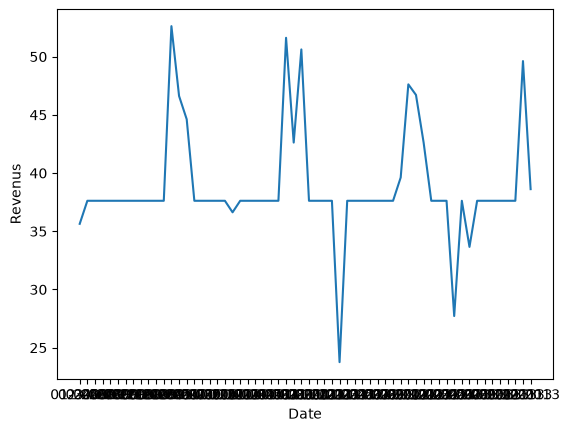

In [3]:
plt.Figure(figsize=(12,8))
sns.lineplot(df, x=df['Date'], y=df['Revenus']) #graphique pour comprendre l'évolution mensuelle

In [4]:
#Passage au format datetime afin d'analyser les périodes

df['Date_Parsed'] = pd.to_datetime(df['Date'])

df['Years'] = df['Date_Parsed'].dt.year
df['Month'] = df['Date_Parsed'].dt.month

df = df.drop('Date_Parsed', axis=1)

df

C:\Users\Alexis\AppData\Local\Temp\ipykernel_12672\3885798966.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date_Parsed'] = pd.to_datetime(df['Date'])


,Date,Revenus,Years,Month
0,01-2009,35.64,2009,1
1,02-2009,37.62,2009,2
2,03-2009,37.62,2009,3
3,04-2009,37.62,2009,4
4,05-2009,37.62,2009,5
5,06-2009,37.62,2009,6
6,07-2009,37.62,2009,7
7,08-2009,37.62,2009,8
8,09-2009,37.62,2009,9
9,10-2009,37.62,2009,10


<Axes: xlabel='Month', ylabel='Revenus'>

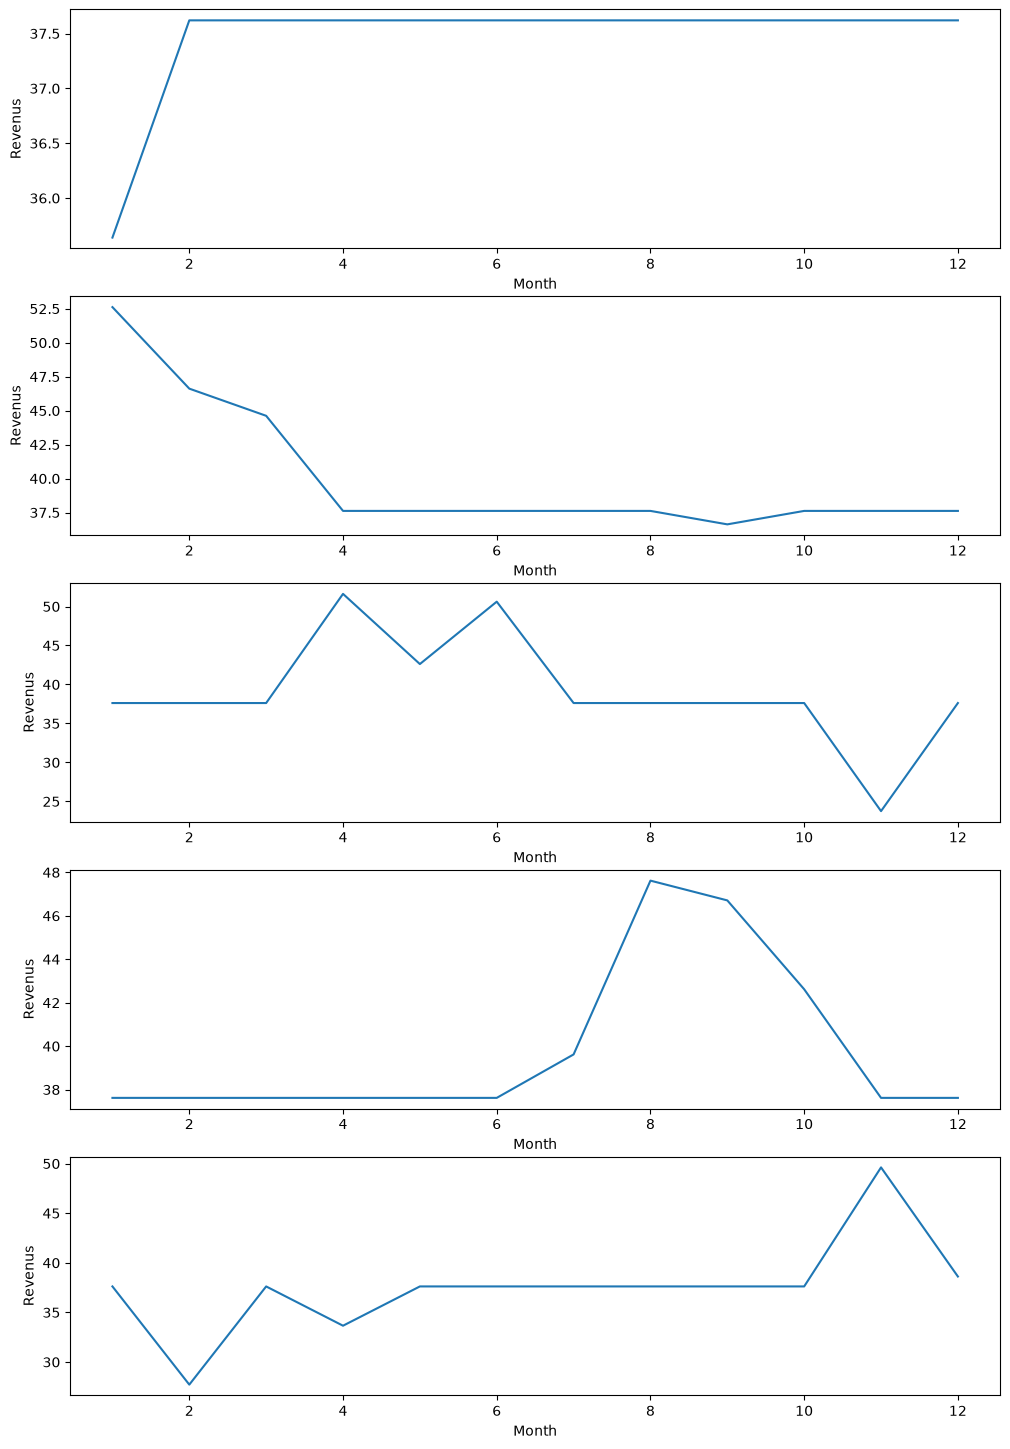

In [5]:
#setup de chaque année : 
df_2009 = df.loc[df['Years'] == 2009]
df_2010 = df.loc[df['Years'] == 2010]
df_2011 = df.loc[df['Years'] == 2011]
df_2012 = df.loc[df['Years'] == 2012]
df_2013 = df.loc[df['Years'] == 2013]

#visualisation graphique des périodes
plt.figure(figsize=(12,18))
plt.subplot(5,1,1)
sns.lineplot(df_2009, x=df_2009['Month'], y=df_2009['Revenus'])
plt.subplot(5,1,2)
sns.lineplot(df_2010, x=df_2010['Month'], y=df_2010['Revenus'])
plt.subplot(5,1,3)
sns.lineplot(df_2011, x=df_2011['Month'], y=df_2011['Revenus'])
plt.subplot(5,1,4)
sns.lineplot(df_2012, x=df_2012['Month'], y=df_2012['Revenus'])
plt.subplot(5,1,5)
sns.lineplot(df_2013, x=df_2013['Month'], y=df_2013['Revenus'])


In [ ]:
pm = pd.read_csv("output_sql/panier_moyen_desc.csv") #analyse statistique du panier moyen

pm.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Client        59 non-null     str    
 1   Panier_Moyen  59 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.1 KB


In [7]:
pm.describe()

,Panier_Moyen
count,59.000000
mean,5.653043
std,0.416765
min,5.374286
25%,5.374286
50%,5.374286
75%,5.731429
max,7.088571


In [8]:
pm['Panier_Moyen'].median().round(2)

np.float64(5.37)

In [ ]:
country = pd.read_csv("output_sql/total_pays.csv")

country

,Country,Total_Pays
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


<Axes: xlabel='Total_Pays', ylabel='Country'>

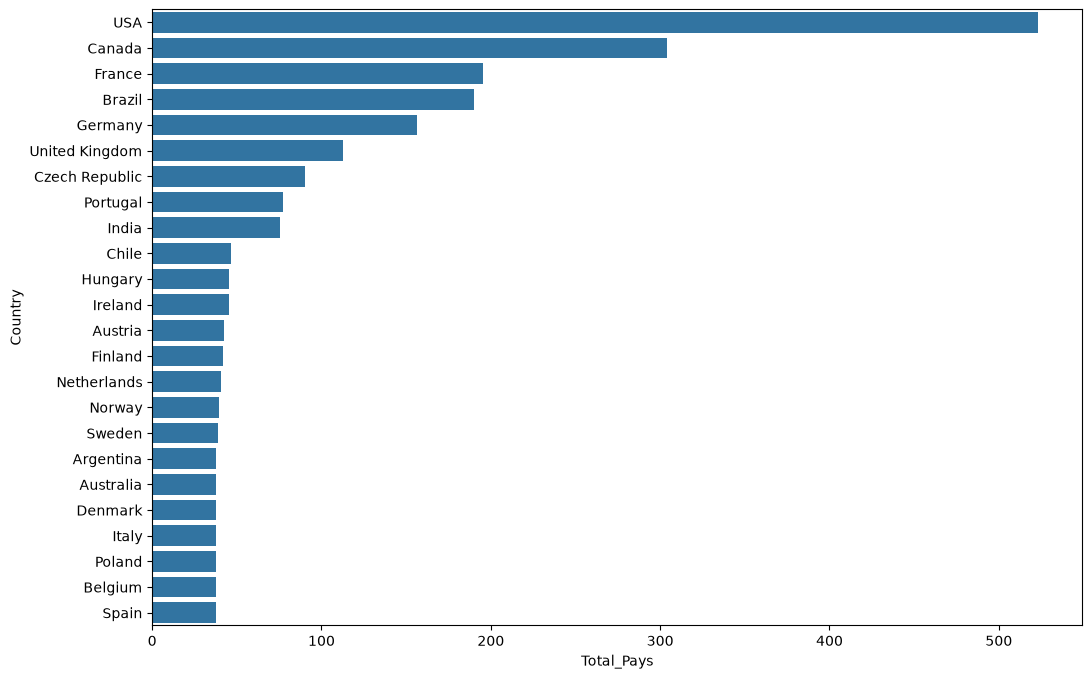

In [10]:
plt.figure(figsize=(12,8))
sns.barplot(x=country['Total_Pays'], y = country['Country'], data = country)

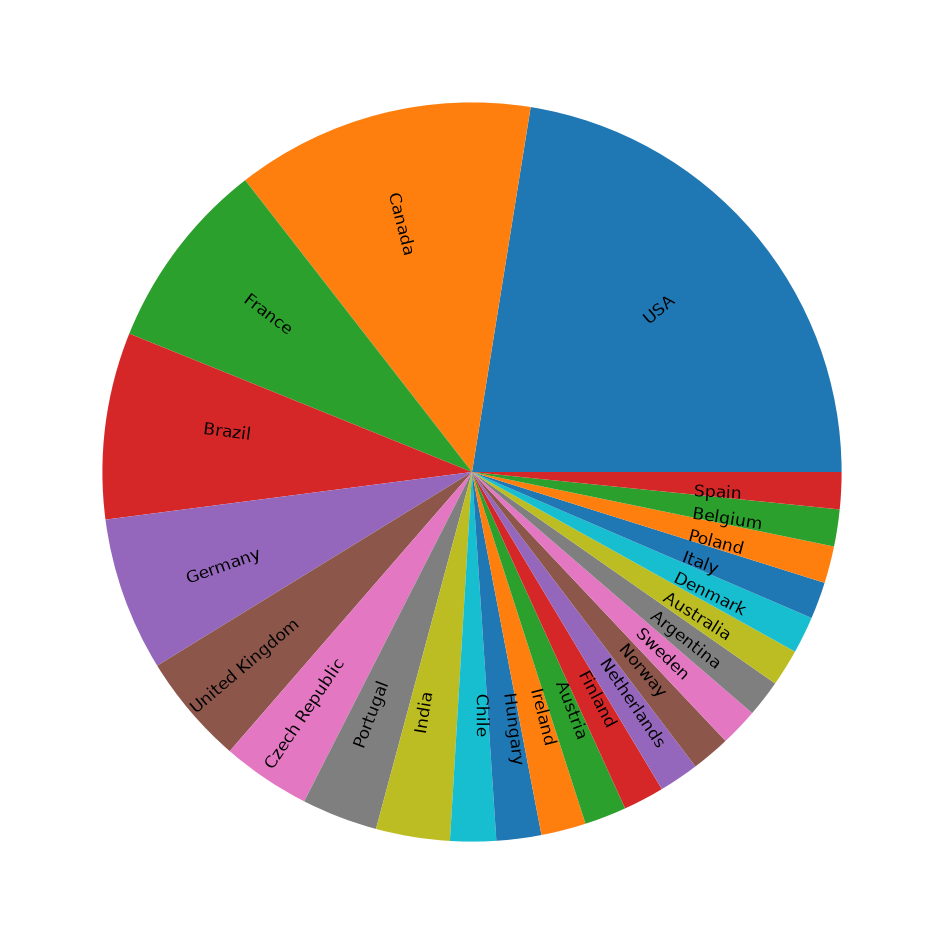

In [12]:
#Graphique circulaire pour voir la répartition

plt.figure(figsize=(15,12))
plt.pie(
    country['Total_Pays'],
    labels=country['Country'],
    labeldistance=0.6,
    rotatelabels=True,
    textprops={'fontsize' : 12}
)